# I. Project Team Members

| Prepared by | Email | Prepared for |
| :-: | :-: | :-: |
| **_Delphino Chew_** | _delphinochew@gmail.com_ | **_Credit Card Fraud Detection_** |

# II. Notebook Target Definition

_The target variable is Class, which indicates whether a credit card transaction is legitimate (0) or fraudulent (1). The analysis will explore the characteristics of the target and its relationship with the available features, while preparing the data for subsequent model development._

# III. Notebook Setup

## III.A. Import Libraries

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

## III.B. Import Data

In [2]:
X = pd.read_pickle('../../data/processed/X.pkl')
y = pd.read_pickle('../../data/processed/y.pkl')

In [3]:
X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [4]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64

# IV. Exploratory Data Analysis

## IV.A. Data Shape Inspection

In [5]:
X.shape, y.shape

((284807, 30), (284807,))

## IV.B. Data Information Inspection

In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 284807 entries, 0 to 284806
Series name: Class
Non-Null Count   Dtype
--------------   -----
284807 non-null  int64
dtypes: int64(1)
memory usage: 2.2 MB


## IV.C. Missing Values Inspection

In [8]:
X_missing = pd.DataFrame(
    X.isnull().sum().sort_values() / len(X) * 100).reset_index()
X_missing.columns = ["variables", "missing_percentage"]
X_missing

,variables,missing_percentage
0,Time,0.0
1,V1,0.0
2,V2,0.0
3,V3,0.0
4,V4,0.0
5,V5,0.0
6,V6,0.0
7,V7,0.0
8,V8,0.0
9,V9,0.0


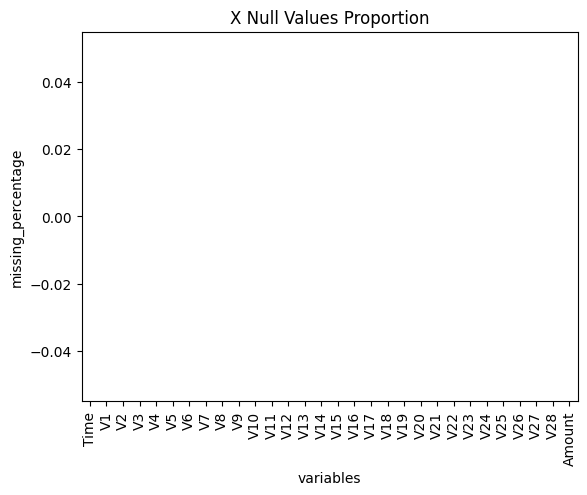

In [9]:
sns.barplot(data=X_missing,
            x="variables",
            y="missing_percentage",
            hue="variables",
            palette='Blues',
            legend=False)
plt.title("X Null Values Proportion")
plt.xticks(rotation='vertical')
plt.show()

## IV.D. Duplicated Values Inspection

In [10]:
# Combine features and target temporarily
df_check = pd.concat([X, y], axis=1)

# Check duplicated rows
print("Number of duplicated rows:", df_check.duplicated().sum())

Number of duplicated rows: 1081


In [11]:
df_check[df_check.duplicated(keep=False)]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283485,171627.0,-1.457978,1.378203,0.811515,-0.603760,-0.711883,-0.471672,-0.282535,0.880654,0.052808,...,0.284205,0.949659,-0.216949,0.083250,0.044944,0.639933,0.219432,0.116772,11.93,0
284190,172233.0,-2.667936,3.160505,-3.355984,1.007845,-0.377397,-0.109730,-0.667233,2.309700,-1.639306,...,0.391483,0.266536,-0.079853,-0.096395,0.086719,-0.451128,-1.183743,-0.222200,55.66,0
284191,172233.0,-2.667936,3.160505,-3.355984,1.007845,-0.377397,-0.109730,-0.667233,2.309700,-1.639306,...,0.391483,0.266536,-0.079853,-0.096395,0.086719,-0.451128,-1.183743,-0.222200,55.66,0
284192,172233.0,-2.691642,3.123168,-3.339407,1.017018,-0.293095,-0.167054,-0.745886,2.325616,-1.634651,...,0.402639,0.259746,-0.086606,-0.097597,0.083693,-0.453584,-1.205466,-0.213020,36.74,0


In [12]:
# Remove the duplicates
df_check = df_check.drop_duplicates()

X = df_check.drop("Class", axis=1)
y = df_check["Class"]

In [14]:
print("Remaining duplicated rows:", df_check.duplicated().sum())
print("New dataset shape:", df_check.shape)

Remaining duplicated rows: 0
New dataset shape: (283726, 31)


### Duplicate Value Handling:

_A total of 1,081 exact duplicate transactions were identified. These duplicate observations were removed to prevent identical records from potentially appearing in both the training and testing sets, which could lead to data leakage and overly optimistic model evaluation._

## IV.E. Data Visualization

### IV.E.1. Target Label Proportion

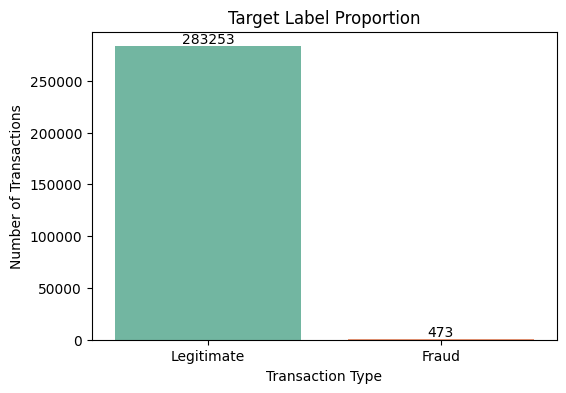

In [15]:
# Bar Plot
plt.figure(figsize=(6, 4))
plt.title("Target Label Proportion")

class_labels = {0: "Legitimate", 1: "Fraud"}

y_proportion = sns.countplot(
    x=y.map(class_labels),
    hue=y.map(class_labels),
    palette="Set2",
    legend=False
)

for container in y_proportion.containers:
    y_proportion.bar_label(container)

plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.show()

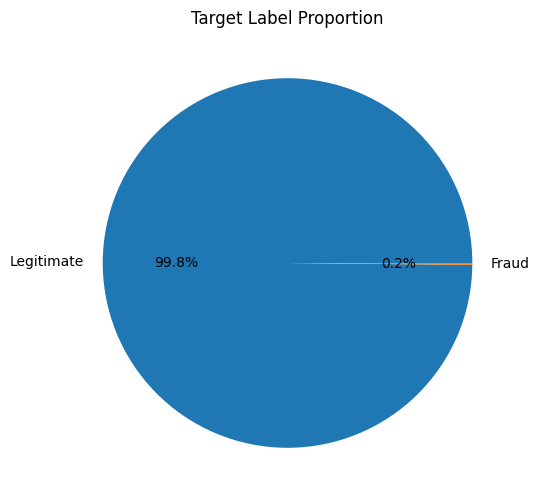

In [16]:
# Pie Chart
plt.figure(figsize=(6, 6))
plt.title("Target Label Proportion")

class_labels = ["Legitimate", "Fraud"]
class_counts = y.value_counts().sort_index()

plt.pie(
    class_counts,
    labels=class_labels,
    autopct="%1.1f%%"
)

plt.show()

### IV.E.2. _Feature_ Distribution

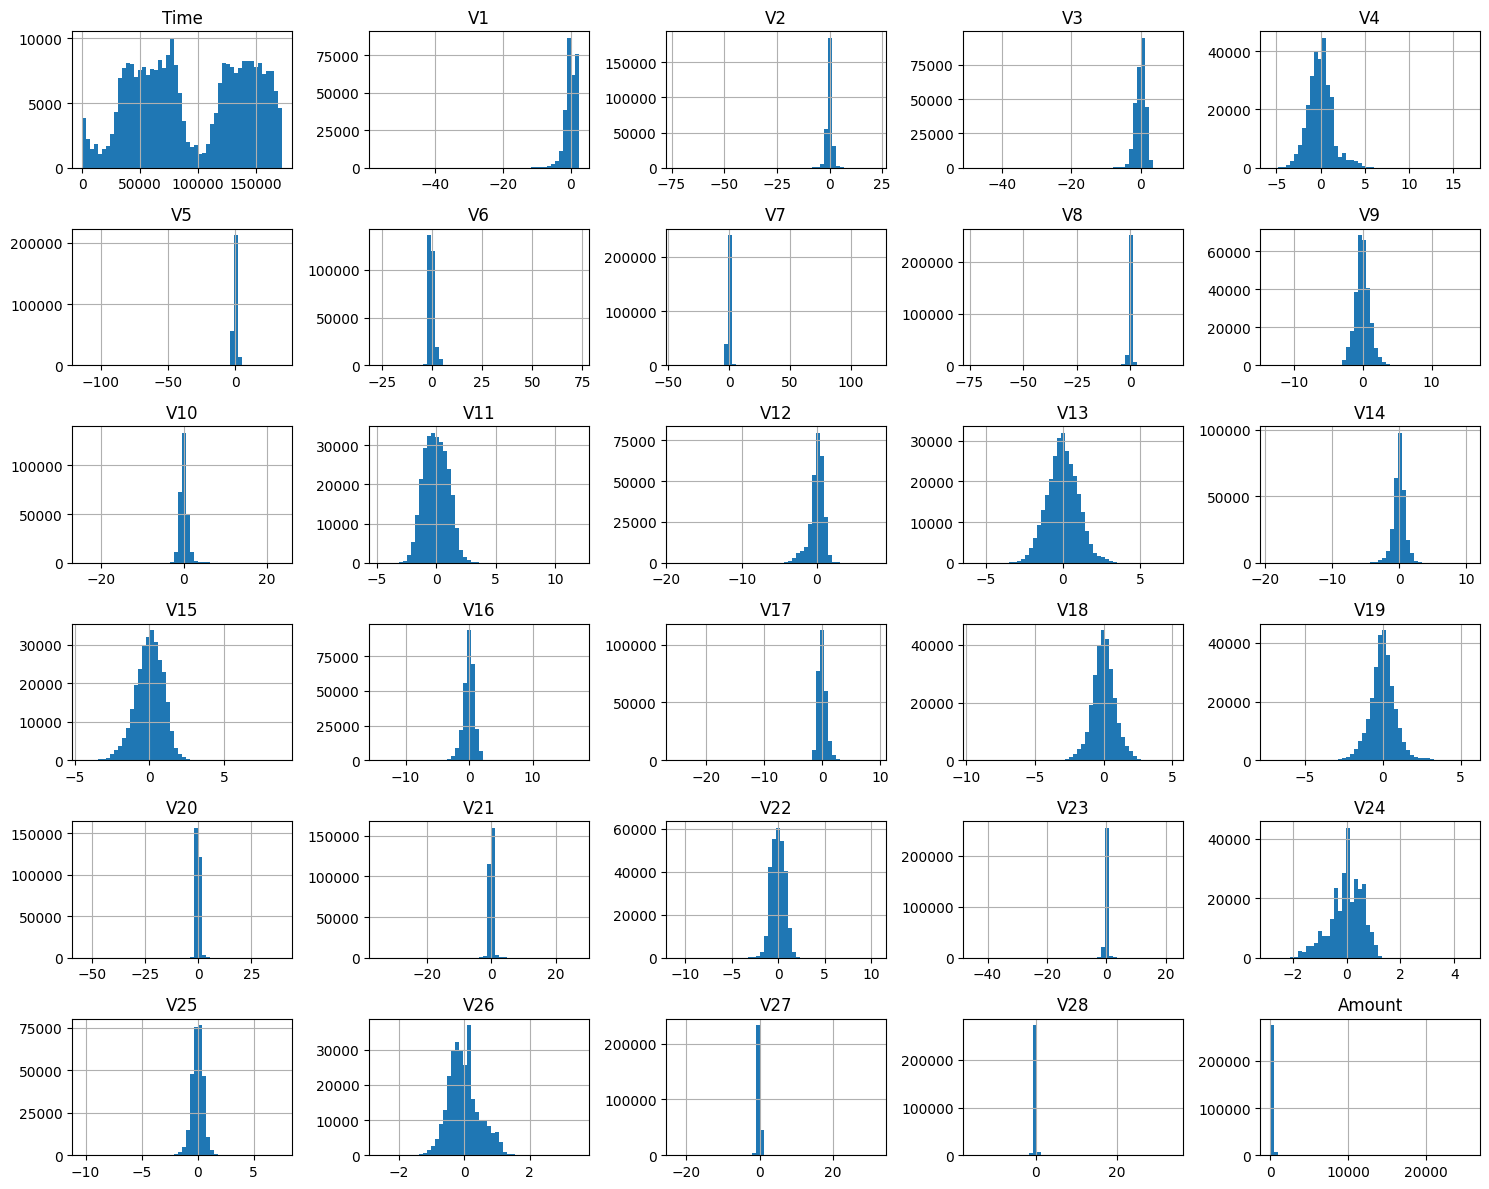

In [ ]:
# Feature Distributions
X.hist(figsize=(15, 12), bins=50)

plt.tight_layout()
plt.show()

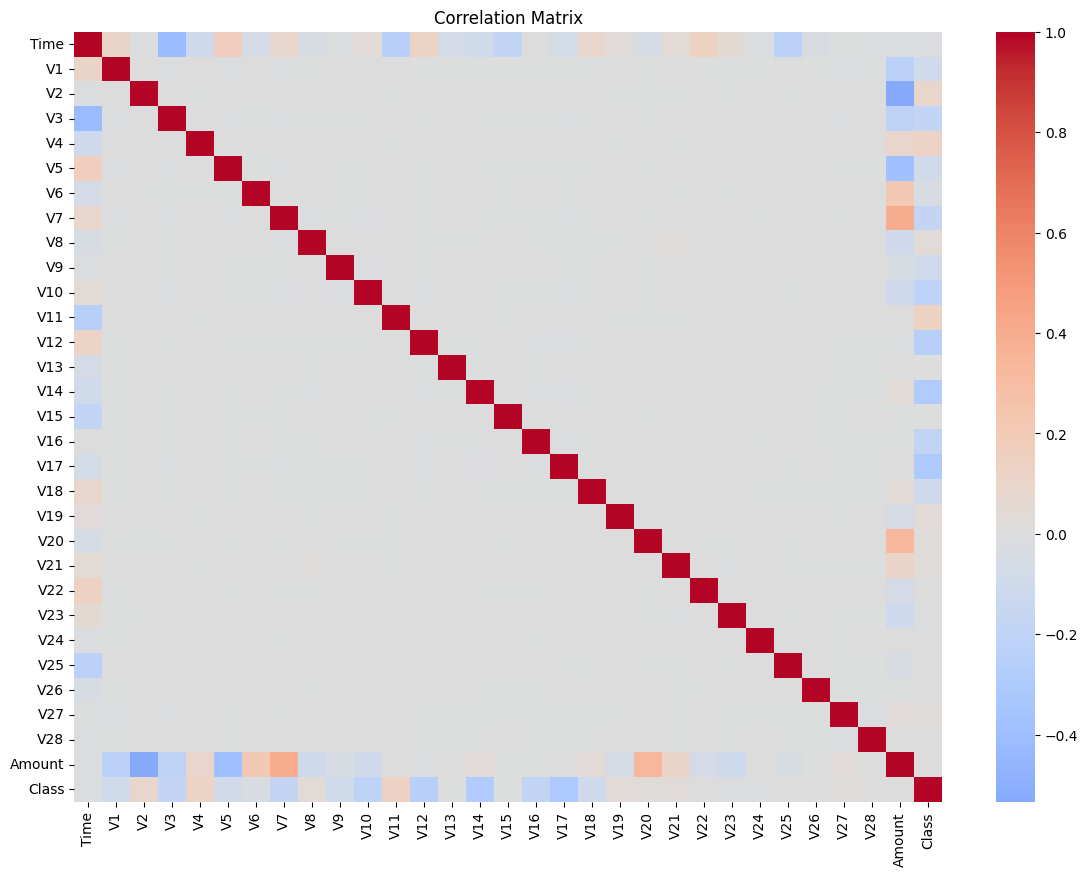

In [22]:
# Correlation Matrix
correlation_matrix = pd.concat([X, y], axis=1).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

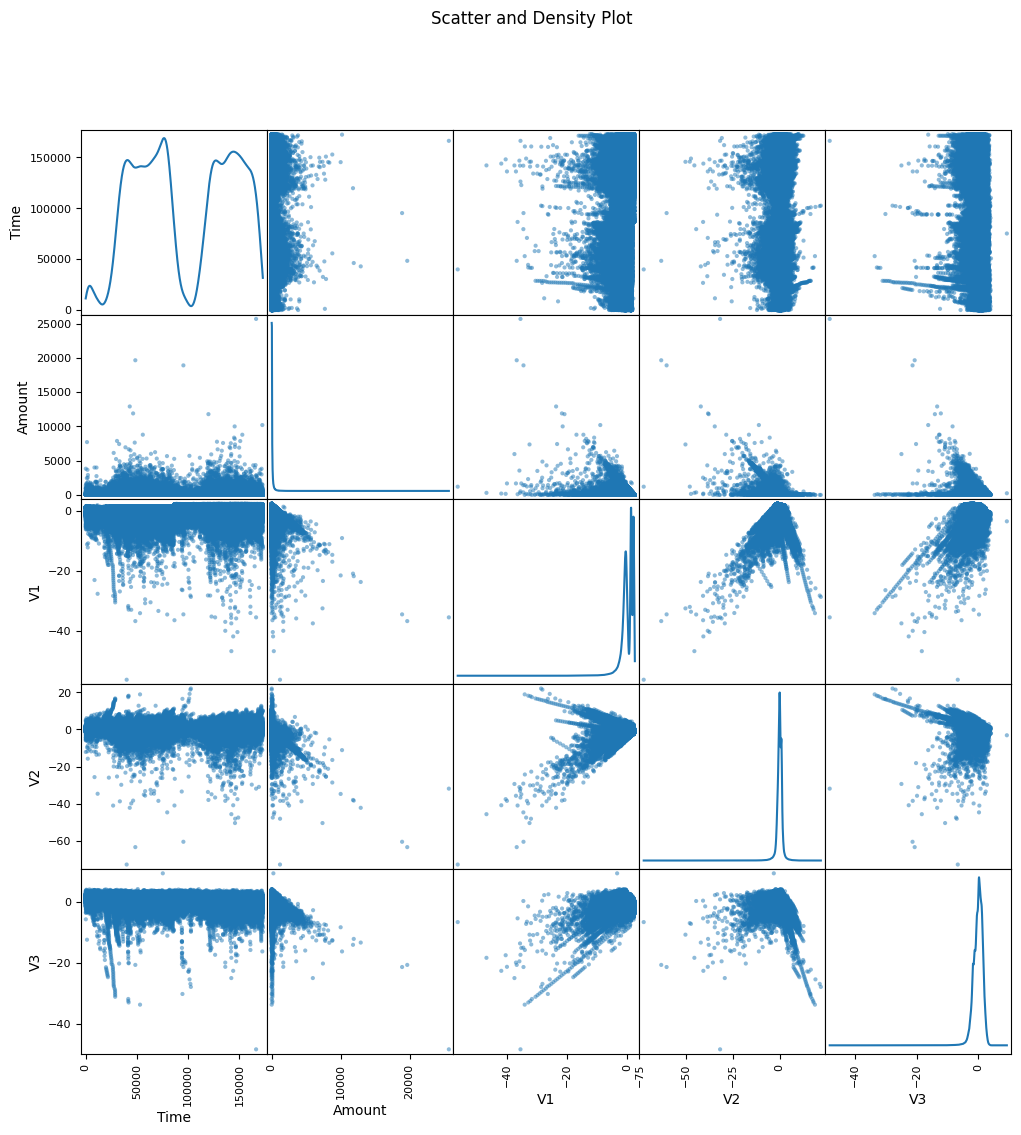

In [21]:
# Density PLot
selected_features = ["Time", "Amount", "V1", "V2", "V3"]

pd.plotting.scatter_matrix(
    X[selected_features],
    figsize=(12, 12),
    diagonal="kde",
    alpha=0.5
)

plt.suptitle("Scatter and Density Plot")
plt.show()

## IV.F. Statistical Analysis

### IV.F.1. Statistical Description

In [18]:
X.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,0.000187,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.769984,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-54.497720,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.211469,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.062353,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.133207,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,39.420904,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000


### IV.F.2. Skewness Analysis

In [23]:
numeric_columns = X.select_dtypes(include=[np.number]).columns
X_skewness = X[numeric_columns].skew()
X_skewness = pd.DataFrame(
    {"variables": X_skewness.index, "skewness": X_skewness.values})

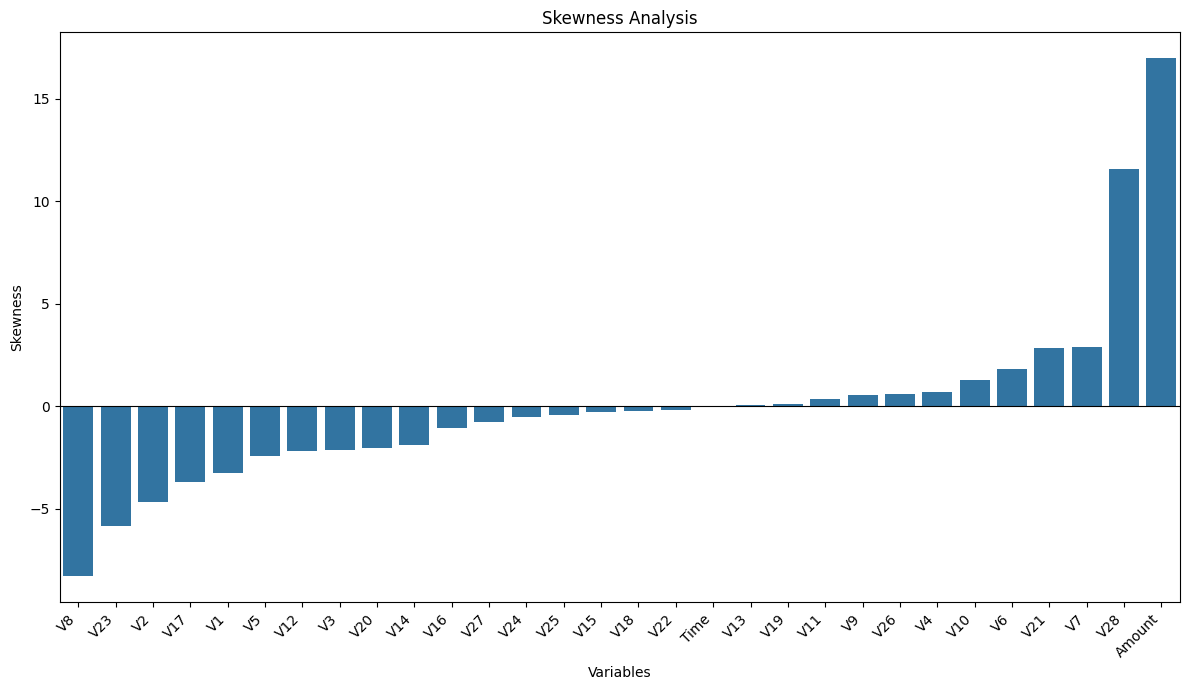

In [29]:
numeric_columns = X.select_dtypes(include=[np.number]).columns

X_skewness = X[numeric_columns].skew()

X_skewness = pd.DataFrame({
    "variables": X_skewness.index,
    "skewness": X_skewness.values
})

X_skewness = X_skewness.sort_values("skewness")

plt.figure(figsize=(12, 7))
plt.title("Skewness Analysis")

skewness_plot = sns.barplot(
    x="variables",
    y="skewness",
    data=X_skewness
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Variables")
plt.ylabel("Skewness")
plt.axhline(y=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

Skewness Analysis: Several features exhibit substantial skewness, with Amount showing particularly strong positive skewness. Several PCA-derived features also display substantial positive or negative skewness. These distributions will be considered when determining appropriate preprocessing techniques.

In [30]:
print(X_skewness)

   variables   skewness
8         V8  -8.310970
23       V23  -5.867221
2         V2  -4.695162
17       V17  -3.690497
1         V1  -3.273271
5         V5  -2.414079
12       V12  -2.199008
3         V3  -2.151984
20       V20  -2.043121
14       V14  -1.918804
16       V16  -1.051161
27       V27  -0.753804
24       V24  -0.552129
25       V25  -0.415744
15       V15  -0.309659
18       V18  -0.248661
22       V22  -0.182330
0       Time  -0.035581
13       V13   0.064293
19       V19   0.108312
11       V11   0.344074
9         V9   0.537663
26       V26   0.580292
4         V4   0.671504
10       V10   1.252967
6         V6   1.829880
21       V21   2.820033
7         V7   2.890271
28       V28  11.555115
29    Amount  16.978803


### IV.F.3. T-Statistics Analysis

Assess if there is a significant difference in means between two groups, such as comparing the mean scores of a continuous variable between two treatment groups.

In [37]:
t_test_results = pd.DataFrame()

for variable in X.columns:
    group_0_values = X.loc[y == 0, variable]
    group_1_values = X.loc[y == 1, variable]

    t_statistic, p_value = stats.ttest_ind(
        group_0_values,
        group_1_values,
        equal_var=False
    )

    result_df = pd.DataFrame({
        "variables": [variable],
        "t-statistic": [t_statistic],
        "p-value": [p_value]
    })

    t_test_results = pd.concat(
        [t_test_results, result_df],
        ignore_index=True
    )

t_test_table = t_test_results.sort_values(
    by="p-value",
    ascending=True
)

t_test_table.reset_index(drop=True, inplace=True)

t_test_table

,variables,t-statistic,p-value
0,V14,35.013621,2.596913e-133
1,V4,-33.947208,8.355934e-129
2,V11,-30.284998,9.849098e-113
3,V12,29.011082,5.558652e-107
4,V10,25.234031,1.408713e-89
5,V16,22.752715,6.514897e-78
6,V9,22.271583,1.192731e-75
7,V3,21.221518,1.125314e-70
8,V17,20.213815,6.494315e-66
9,V6,18.169363,2.402860e-56


T-Statistical Analysis: Welch's t-tests were conducted to compare the means of each numerical feature between legitimate and fraudulent transactions. Most variables showed statistically significant differences between the two classes. However, statistical significance does not directly indicate predictive importance, and the results are therefore treated as exploratory findings rather than a basis for feature selection.

### IV.F.4. ANOVA F Analysis

Compare more than two groups, such as comparing the mean scores of a continuous variable among different experimental conditions.

In [40]:
f_statistic, p_values = f_classif(X, y)

anova_f_table = pd.DataFrame({
    "variables": X.columns,
    "f-score": f_statistic,
    "p-value": p_values
})

anova_f_table.sort_values(
    by="f-score",
    ascending=False,
    inplace=True,
    ignore_index=True
)

anova_f_table

,variables,f-score,p-value
0,V17,30923.969703,0.000000e+00
1,V14,26719.606942,0.000000e+00
2,V12,19029.929570,0.000000e+00
3,V10,12697.850513,0.000000e+00
4,V16,10302.274423,0.000000e+00
5,V3,9755.675863,0.000000e+00
6,V7,8685.536141,0.000000e+00
7,V11,6447.910427,0.000000e+00
8,V4,4826.048761,0.000000e+00
9,V18,3183.658090,0.000000e+00


ANOVA F Analysis: The ANOVA F-test indicates statistically significant differences between legitimate and fraudulent transactions for most numerical features. Variables such as V17, V14, V12, and V10 exhibit particularly large F-statistics. These results provide evidence of univariate differences between the two classes but are not used alone to determine feature importance or selection.

## IV.G. Correlation Analysis

In [ ]:
# Correlation Analysis
corr_matrix = X.corr()

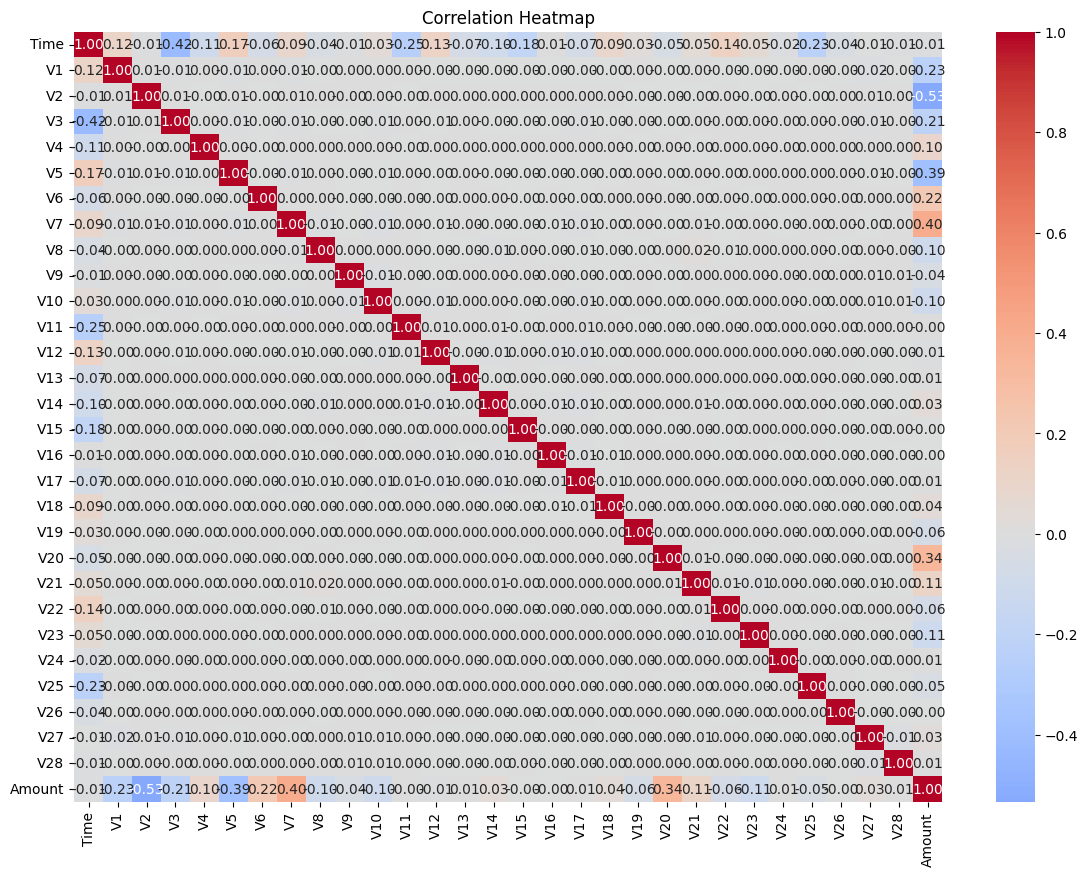

In [42]:
plt.figure(figsize=(14, 10))
plt.title("Correlation Heatmap")

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm"
)

plt.show()

In [ ]:
high_corr_list = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            colname1 = corr_matrix.columns[i]
            colname2 = corr_matrix.columns[j]

            high_corr_list.append([
                colname1,
                colname2,
                corr_matrix.iloc[i, j]
            ])

high_corr_df = pd.DataFrame(
    high_corr_list,
    columns=["column_1", "column_2", "correlation_value"]
)

high_corr_df

,column_1,column_2,correlation_value


Correlation Analysis: No pairs of predictor variables exhibited a strong linear correlation (|r| > 0.7). Therefore, there is no immediate indication of substantial multicollinearity among the features based on this threshold.

# V. Preprocessing

## V.A. Log Transformation of Amount

In [45]:
# Apply log transformation to reduce right skewness
X["Amount"] = np.log1p(X["Amount"])

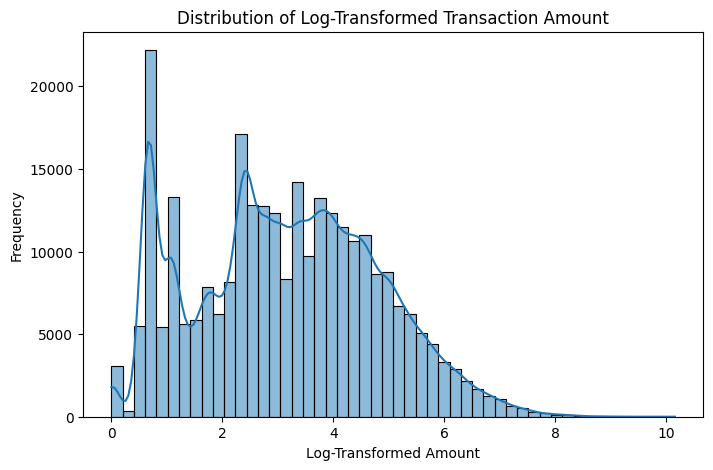

In [46]:
plt.figure(figsize=(8, 5))

sns.histplot(X["Amount"], bins=50, kde=True)

plt.title("Distribution of Log-Transformed Transaction Amount")
plt.xlabel("Log-Transformed Amount")
plt.ylabel("Frequency")

plt.show()

In [47]:
amount_skewness = X["Amount"].skew()

print("Skewness of log-transformed Amount:", amount_skewness)

Skewness of log-transformed Amount: 0.16141018223366638


## V.B. Data Splitting

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [56]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (226980, 30)
X_test: (56746, 30)
y_train: (226980,)
y_test: (56746,)


In [57]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training class distribution:
Class
0    0.998335
1    0.001665
Name: proportion, dtype: float64

Testing class distribution:
Class
0    0.998326
1    0.001674
Name: proportion, dtype: float64


## V.C. Export Data

In [75]:
X_train.to_pickle('../../data/processed/X_train.pkl')
X_test.to_pickle('../../data/processed/X_test.pkl')

y_train.to_pickle('../../data/processed/y_train.pkl')
y_test.to_pickle('../../data/processed/y_test.pkl')